# 1. Setup

In [17]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             roc_auc_score,
                             confusion_matrix,
                             classification_report)

# ML: TabPFN
from tabpfn import TabPFNClassifier

# ML: Torch
import torch

# Explainability
import shap
import pickle
import dice_ml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.express as px

# Saving models
import joblib

print("Core libraries loaded.")

Core libraries loaded.


In [18]:
# Setting up the GPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("Using CPU.")

GPU: NVIDIA GeForce RTX 3060 Ti


In [19]:
# Constants
random_state = 8 # Lucky Number
years = ["2020", "2021", "2022", "2024"]

features_const = ["ID", "SEX"]
features = ["AGE", "MARRIED", "CHILD", "HINCOME_group", "JOB_group",
            "Exercise", "HealthyDiet", "Activity", "Interaction_offline",
            "Interaction_online", "Altruistic", "Optimism", "HealthySleep",
            "DeteriorationEconomy", "DeteriorationInteract", "Frustration",
            "CovidAnxiety", "CovidSleepless", "Difficultyliving", "DifficultyWork"]
target = "UCLA"

features_UCLA = ["Sex_Male", "Age", "Is_Married", "Has_Child", "Income", "Income_Missing",
                 "Job_Employed", "Job_Homemaker", "Job_Student", "Job_Unemployed", "Job_Other",
                 "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
                 "Interaction_Offline", "Interaction_Online",
                 "Altruistic", "Frustration", "Optimism",
                 "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy", "Deterioration_Interact",
                 "Difficulty_Living", "Difficulty_Work"]
target_UCLA = "UCLA_High"
vars_UCLA = ["ID", "Phase", "Year"]
UCLA_cutoff = 22

In [20]:
# =====================================================================
# XAI QUICK-RUN CONFIGURATION
# =====================================================================

# Number of background samples for SHAP KernelExplainer
# Debug: 20–50. Full run: 100–200.
N_SHAP_BACKGROUND = 30

# Number of test samples to compute SHAP values for
# Debug: 10–20 (minutes). Full run: len(X_test) or 200+ (hours).
N_SHAP_EXPLAIN = 10

# Number of test samples to generate counterfactuals for
# Debug: 3–5 (fast). Full run: 20–50+.
N_CF_SAMPLES = 5

# Number of counterfactual examples to generate per sample
# Debug: 3. Full run: 5–10.
N_CF_PER_SAMPLE = 3

# Number of top features to show in dependence plots
# Debug: 3. Full run: 5–10.
N_TOP_FEATURES = 3

In [21]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

# 2. Dataset Loading & Preprocessing

In [22]:
DATA_PATH = "../../data/dataset.csv"

df = pd.read_csv(DATA_PATH, na_values=["NA", "N/A", "NaN", "null", "NULL", "", " ", "-"])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2659 rows, 106 columns


,ID,SEX,AGE_1,MARRIED_1,CHILD_1,HINCOME_group_1,JOB_group_1,LSNS_group_1,K6_1,PHQ9_1,...,Altruistic_4,Optimism_4,HealthySleep_4,DeteriorationEconomy_4,DeteriorationInteract_4,Frustration_4,CovidAnxiety_4,CovidSleepless_4,Difficultyliving_4,DifficultyWork_4
0,1,1,53,2,2,4.0,1,1,3,8,...,5,4,4,4,3,3,5,5,5,5
1,2,2,66,2,2,5.0,2,0,1,0,...,7,7,7,1,1,1,5,1,1,6
2,3,1,48,1,1,3.0,1,1,3,6,...,1,3,5,4,1,1,1,1,1,1
3,4,1,62,2,2,5.0,1,1,0,0,...,1,5,5,1,1,1,1,1,1,1
4,5,1,59,2,2,5.0,1,0,1,6,...,2,5,5,4,4,4,4,2,4,4


In [23]:
# Reshape longitudinal data
df_prep_list = []
for i, year in enumerate(years, 1):
    current_features = [f"{col}_{i}" for col in features]
    current_target = [f"{col}_{i}" for col in [target]]
    cols_to_select = features_const + current_features + current_target
    temp_df = df[cols_to_select].copy()
    rename_mapping = {f"{col}_{i}": col for col in features + [target]}
    temp_df = temp_df.rename(columns=rename_mapping)
    temp_df["Phase"] = i
    temp_df["Year"] = year
    df_prep_list.append(temp_df)

df_prep = pd.concat(df_prep_list, ignore_index=True)
print(f"Reshaped: {df_prep.shape}")

Reshaped: (10636, 25)


In [24]:
# Handle missing data
missing_values = df_prep.isnull().sum()
missing_percent = 100 * df_prep.isnull().sum() / len(df_prep)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)

,Missing Count,Missing Percentage
HINCOME_group,1860,17.487777


In [25]:
# Encode categorical features
df_encoded = df_prep.copy()
df_encoded["Sex_Male"] = (df_encoded["SEX"] == 1).astype(int)
df_encoded["Is_Married"] = (df_encoded["MARRIED"] == 2).astype(int)
df_encoded["Has_Child"] = (df_encoded["CHILD"] == 2).astype(int)
df_encoded["Income_Missing"] = df_encoded["HINCOME_group"].isna().astype(int)
df_encoded["Income"] = df_encoded["HINCOME_group"].fillna(0).astype(int)

job_map = {1: "Job_Employed", 2: "Job_Homemaker", 3: "Job_Student",
           4: "Job_Unemployed", 5: "Job_Other"}
job_labels = df_encoded["JOB_group"].astype("Int64").map(job_map)
job_encoding = pd.get_dummies(job_labels, dtype=int)
df_encoded = pd.concat([df_encoded, job_encoding], axis=1)

df_encoded = df_encoded.rename(columns={
    "AGE": "Age", "HealthyDiet": "Healthy_Diet", "HealthySleep": "Healthy_Sleep",
    "Interaction_offline": "Interaction_Offline", "Interaction_online": "Interaction_Online",
    "CovidAnxiety": "Covid_Anxiety", "CovidSleepless": "Covid_Sleepless",
    "DeteriorationEconomy": "Deterioration_Economy",
    "DeteriorationInteract": "Deterioration_Interact",
    "Difficultyliving": "Difficulty_Living", "DifficultyWork": "Difficulty_Work"
})

df_encoded[target_UCLA] = (df_encoded["UCLA"] >= UCLA_cutoff).astype(int)
df_encoded = df_encoded.drop(columns=["SEX", "MARRIED", "CHILD", "HINCOME_group", "JOB_group", "UCLA"])
df_encoded = df_encoded[vars_UCLA + features_UCLA + [target_UCLA]]
print(f"Encoded: {df_encoded.shape}")
print(f"Target distribution:\n{df_encoded[target_UCLA].value_counts()}")

Encoded: (10636, 30)
Target distribution:
UCLA_High
1    7128
0    3508
Name: count, dtype: int64


# 3. EDA

In [26]:
# Statistical
df_encoded.describe()

,ID,Phase,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
count,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,...,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000
mean,1330.000000,2.500000,0.582926,53.791087,0.644321,0.570985,2.720666,0.174878,0.687759,0.139150,...,5.087909,3.031685,4.112354,3.291087,2.356149,3.493983,2.537890,2.646296,2.796822,0.670177
std,767.623216,1.118087,0.493099,12.784209,0.478741,0.494959,1.737744,0.379880,0.463430,0.346119,...,1.843496,1.683804,1.550914,1.686384,1.472101,1.702638,1.523418,1.641990,1.751135,0.470171
min,1.000000,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,665.000000,1.750000,0.000000,45.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1330.000000,2.500000,1.000000,54.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,...,5.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000
75%,1995.000000,3.250000,1.000000,63.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,7.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
max,2659.000000,4.000000,1.000000,92.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1.000000


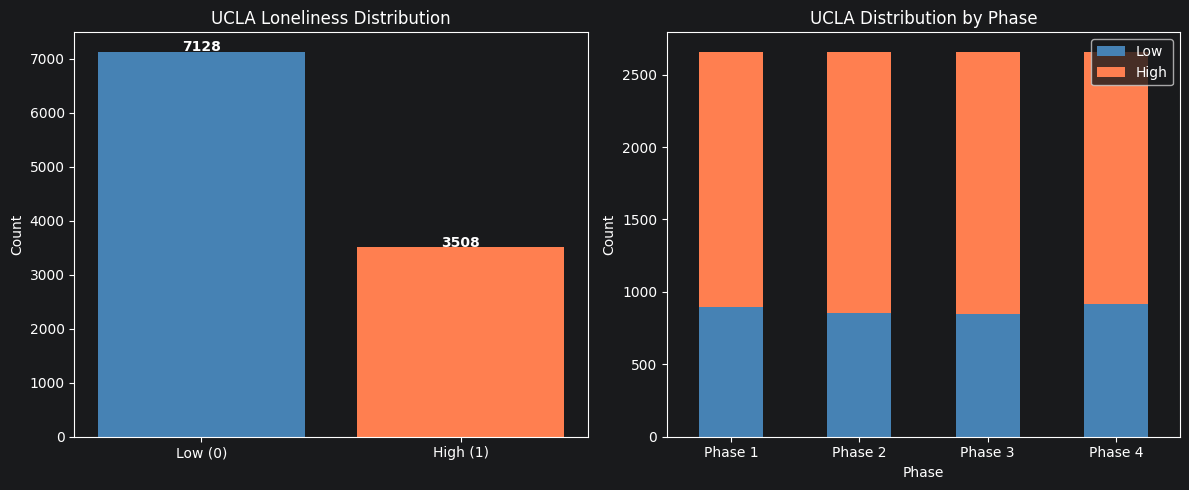

In [27]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_encoded[target_UCLA].value_counts()
axes[0].bar(["Low (0)", "High (1)"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("UCLA Loneliness Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

phase_target = df_encoded.groupby("Phase")[target_UCLA].value_counts().unstack(fill_value=0)
phase_target.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("UCLA Distribution by Phase")
axes[1].set_ylabel("Count")
axes[1].legend(["Low", "High"])
axes[1].set_xticklabels([f"Phase {i}" for i in range(1, 5)], rotation=0)

plt.tight_layout()
plt.show()

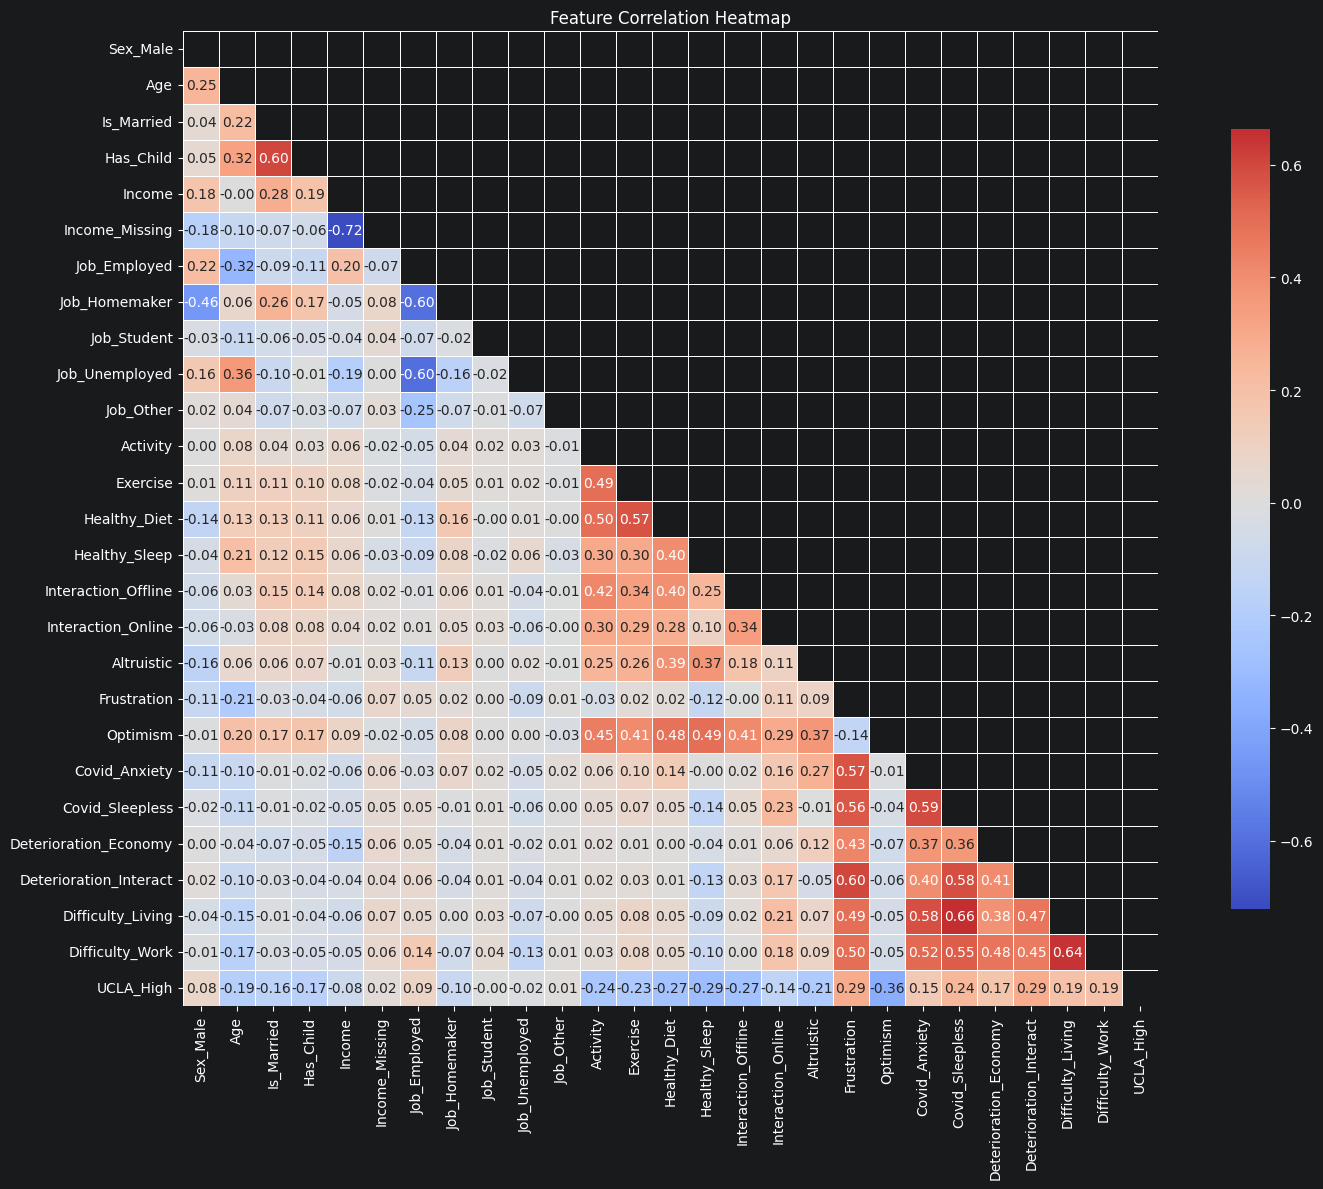

In [28]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df_encoded[features_UCLA + [target_UCLA]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

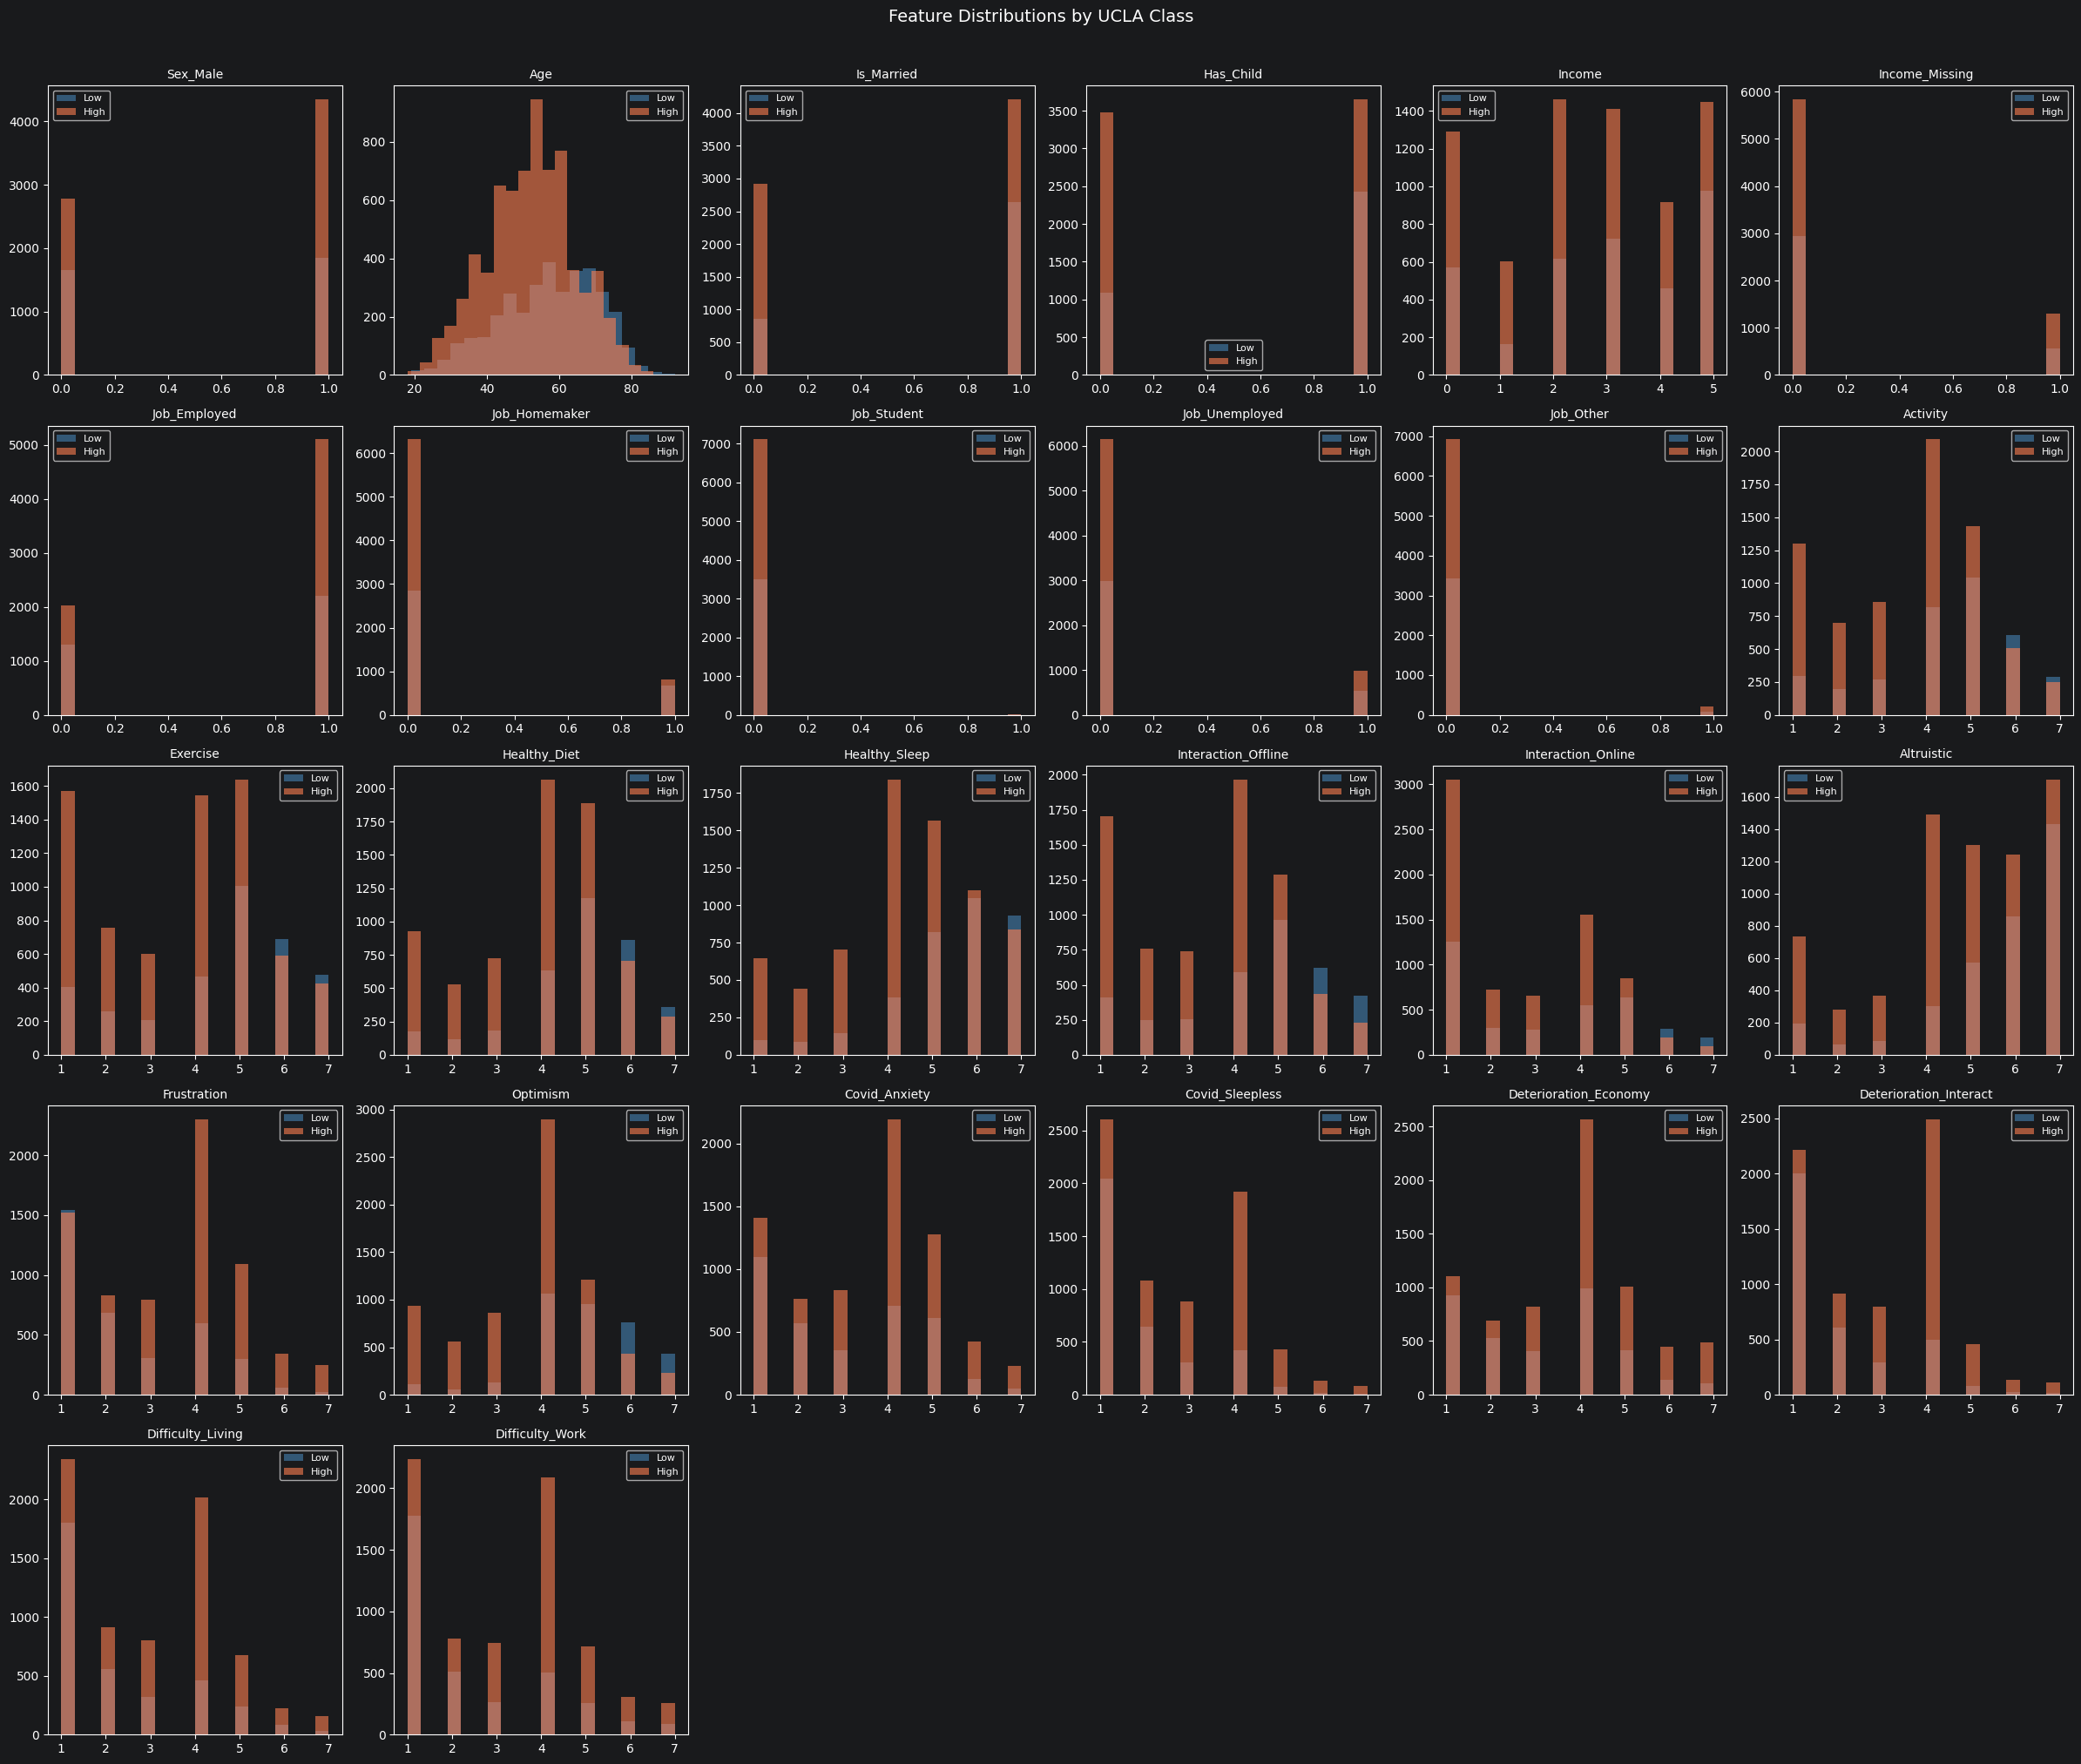

In [29]:
# Feature distributions by target class
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(features_UCLA):
    if i < len(axes):
        for label, color in zip([0, 1], ["steelblue", "coral"]):
            subset = df_encoded[df_encoded[target_UCLA] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                        label="Low" if label == 0 else "High")
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(features_UCLA), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by UCLA Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train-Test Split

In [30]:
df_ml = df_encoded.copy()
df_train = df_ml[df_ml["Phase"].isin([1, 2, 3])].copy()
df_test = df_ml[df_ml["Phase"] == 4].copy()

ignore_feats = vars_UCLA
X_train = df_train.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_train = df_train[target_UCLA]
X_test = df_test.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_test = df_test[target_UCLA]

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7977 samples, 26 features
Testing set:  2659 samples, 26 features

Training target distribution:
UCLA_High
1    5382
0    2595
Name: count, dtype: int64

Test target distribution:
UCLA_High
1    1746
0     913
Name: count, dtype: int64


# 5. Baseline Model Training

In [31]:
# Define all models with default hyperparameters
models = [
    ("TabPFN", TabPFNClassifier(device=device, random_state=random_state))
]

In [32]:
# Train and evaluate all baseline models
results = []
trained_models = {}
cm_data = {}

for name, model in models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    # Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print(f"  Train:    {format_time(train_time)}")
    print(f"  Predict:  {format_time(test_time)}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Low', 'High'])}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC AUC": auc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

    trained_models[name] = model
    cm_data[name] = confusion_matrix(y_test, y_pred)

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  TabPFN (baseline)
  Accuracy: 0.7785
  F1-Score: 0.8395
  ROC AUC:  0.8426
  Train:    0.77s
  Predict:  8.22s

              precision    recall  f1-score   support

         Low       0.72      0.58      0.64       913
        High       0.80      0.88      0.84      1746

    accuracy                           0.78      2659
   macro avg       0.76      0.73      0.74      2659
weighted avg       0.77      0.78      0.77      2659


  All baseline models trained.


# 6. Results & Comparison

In [33]:
# Confusion matrices
for name in cm_data:
    cm = cm_data[name]
    fig_cm = ff.create_annotated_heatmap(
        z=cm.tolist(),
        x=["Predicted Low", "Predicted High"],
        y=["Actual Low", "Actual High"],
        annotation_text=[[str(y) for y in x] for x in cm.tolist()],
        colorscale="Viridis"
    )
    fig_cm.update_layout(title_text=f"Confusion Matrix (Baseline): {name}",
                         yaxis=dict(autorange="reversed"), height=350)
    fig_cm.show()

# 7. Save Models & Results

In [34]:
# Save all models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    save_path = f"models/{safe_name}.joblib"
    joblib.dump(model, save_path)
    print(f"Saved: {save_path}")

# Save results
df_results.to_csv("models/baseline_results.csv", index=False)
print("\nBaseline results saved to models/baseline_results.csv")

# Save training data
X_train.to_csv("artifacts/X_train.csv", index=False)
X_test.to_csv("artifacts/X_test.csv", index=False)
y_train.to_csv("artifacts/y_train.csv", index=False)
y_test.to_csv("artifacts/y_test.csv", index=False)
print("Training/test data saved.")

Saved: models/tabpfn.joblib

Baseline results saved to models/baseline_results.csv
Training/test data saved.


# 8. SHAP Explanations

In [35]:
# Background summary for KernelExplainer
print(f"Creating SHAP background summary (k={N_SHAP_BACKGROUND})...")
background = shap.kmeans(X_train, N_SHAP_BACKGROUND)
print("Done.")

Creating SHAP background summary (k=30)...
Done.


In [36]:
# Create KernelExplainer using the baseline TabPFN model
print("Initializing SHAP KernelExplainer...")
shap_explainer = shap.KernelExplainer(model.predict_proba, background)
print("Explainer ready.")

Initializing SHAP KernelExplainer...
Explainer ready.


In [37]:
# Compute SHAP values on a subset of the test set.
X_explain = X_test.iloc[:N_SHAP_EXPLAIN].copy()

print(f"Computing SHAP values for {len(X_explain)} test samples (this may take a while)...")
start_time = time.time()

shap_values = shap_explainer.shap_values(X_explain)

elapsed = time.time() - start_time
print(f"SHAP values computed in {format_time(elapsed)}")
print(f"Shape: {np.array(shap_values).shape}  (classes x samples x features)")

Computing SHAP values for 10 test samples (this may take a while)...


100%|██████████| 10/10 [10:42<00:00, 64.27s/it]

SHAP values computed in 10m 42.72s
Shape: (10, 26, 2)  (classes x samples x features)


In [40]:
# Save SHAP artifacts
with open("explainers/shap_values_test.pkl", "wb") as f:
    pickle.dump(shap_values, f)

with open("explainers/shap_expected_value.pkl", "wb") as f:
    pickle.dump(np.array(shap_explainer.expected_value), f)

print("SHAP values and expected values saved.")

SHAP values and expected values saved.


## 3.1 Global Feature Importance

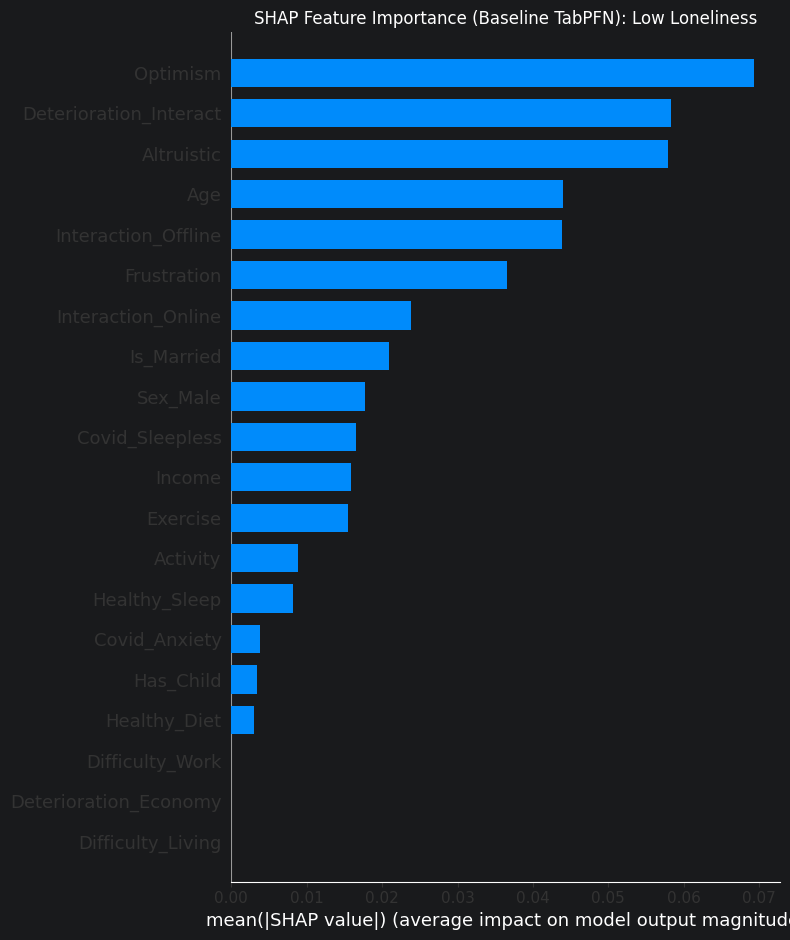

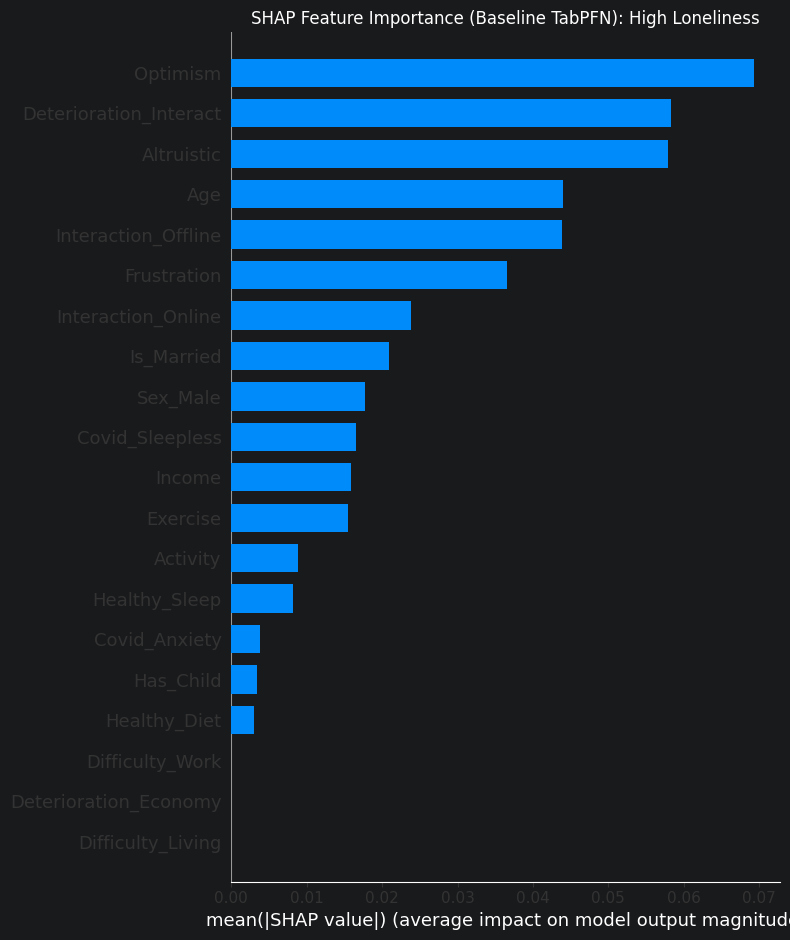

In [48]:
features_list = X_train.columns.tolist()
class_names = ["Low Loneliness", "High Loneliness"]

for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values[:, :, i],
                      X_explain,
                      feature_names=features_list,
                      plot_type="bar",
                      show=False,
                      max_display=20)
    plt.title(f"SHAP Feature Importance (Baseline TabPFN): {class_name}")
    plt.tight_layout()
    plt.show()

## 3.2 Feature Effects

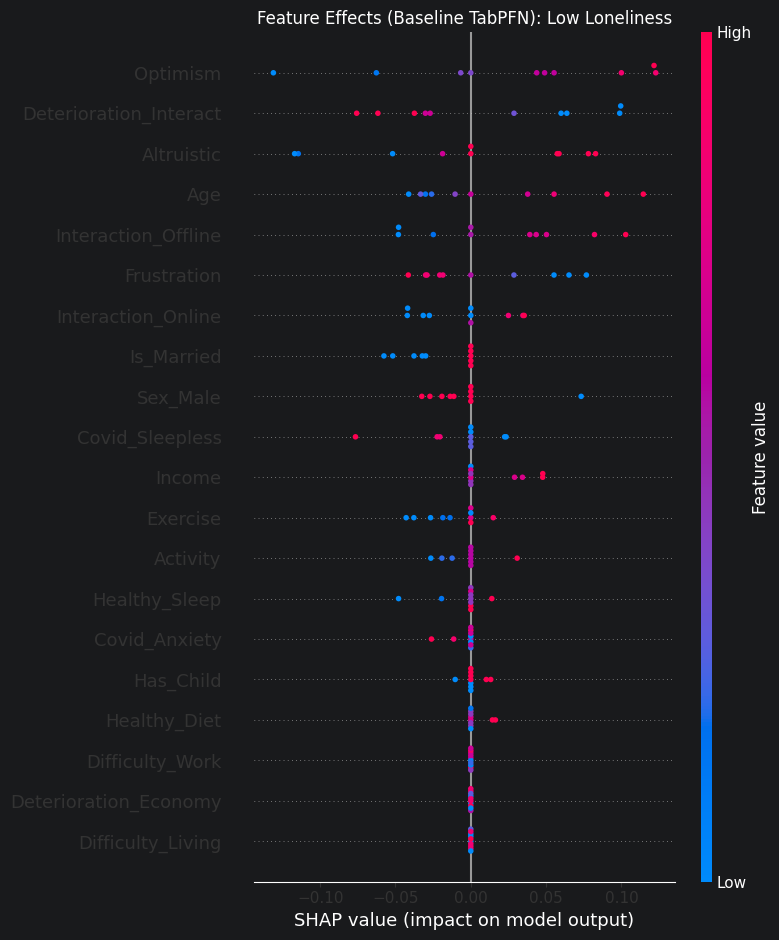

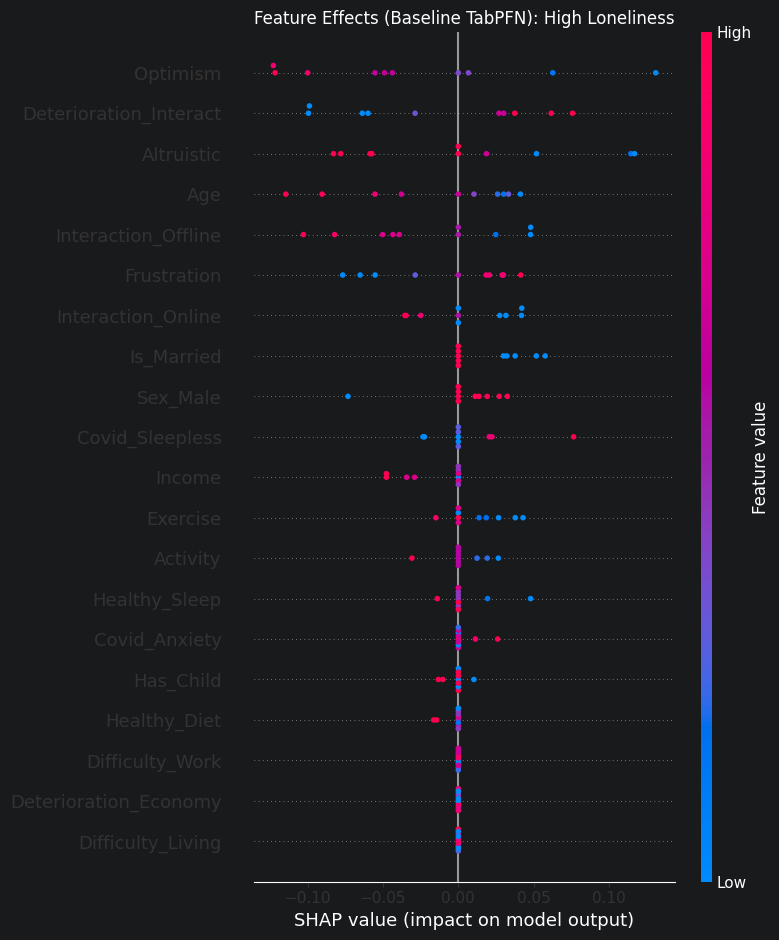

In [50]:
for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values[:, :, i],
                      X_explain,
                      feature_names=features_list,
                      show=False,
                      max_display=20)
    plt.title(f"Feature Effects (Baseline TabPFN): {class_name}")
    plt.tight_layout()
    plt.show()

## 3.3 Dependence Plots

Top 3 features by mean |SHAP| (High Loneliness):
  1. Age = 0.0248
  2. Sex_Male = 0.0248


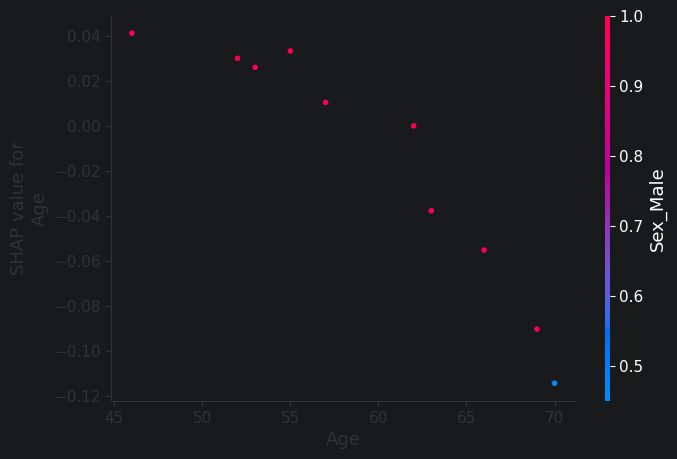

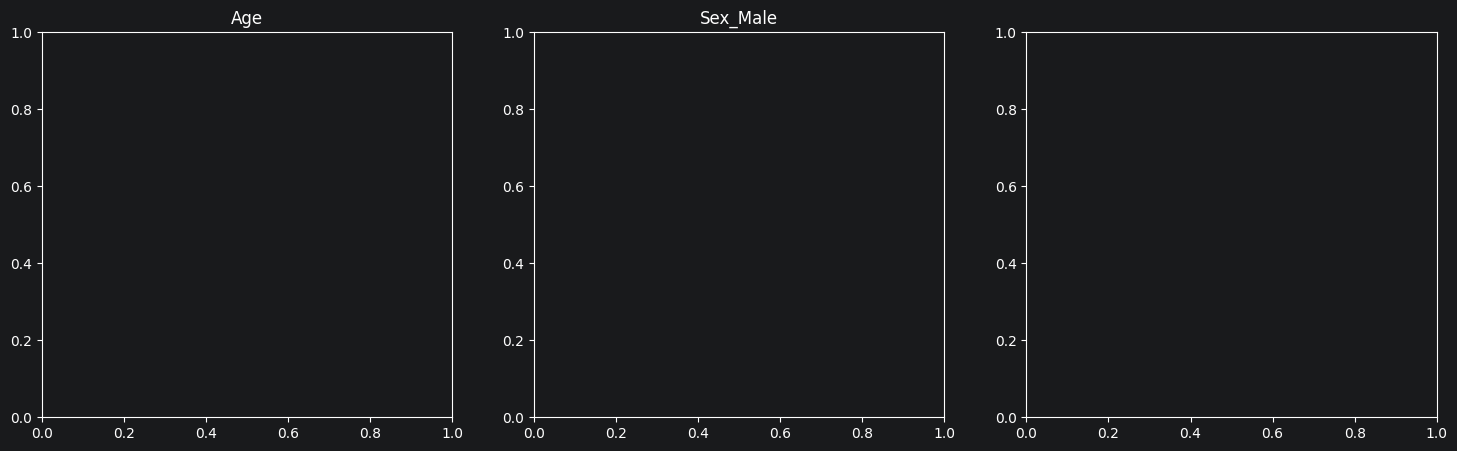

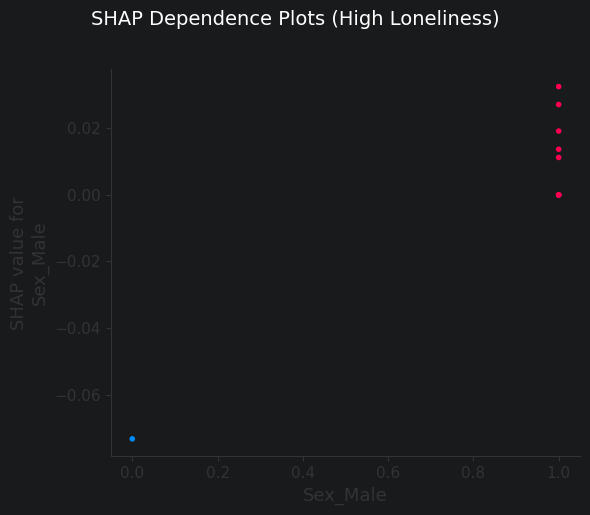

In [51]:
# Dependence plots for the top-N most important features (High Loneliness class).
mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-N_TOP_FEATURES:][::-1]
top_feature_names = [features_list[j] for j in top_indices]

print(f"Top {N_TOP_FEATURES} features by mean |SHAP| (High Loneliness):")
for rank, (idx, name) in enumerate(zip(top_indices, top_feature_names), 1):
    print(f"  {rank}. {name} = {mean_abs_shap[idx]:.4f}")

fig, axes = plt.subplots(1, N_TOP_FEATURES, figsize=(6 * N_TOP_FEATURES, 5))
if N_TOP_FEATURES == 1:
    axes = [axes]

for ax, feat_idx, feat_name in zip(axes, top_indices, top_feature_names):
    plt.sca(ax)
    shap.dependence_plot(feat_idx,
                         shap_values[:, :, 1],
                         X_explain,
                         feature_names=features_list,
                         interaction_index="auto",
                         show=False)
    ax.set_title(feat_name)

plt.suptitle("SHAP Dependence Plots (High Loneliness)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Sample 0: Predicted = High Loneliness
  P(Low)  = 0.145
  P(High) = 0.855


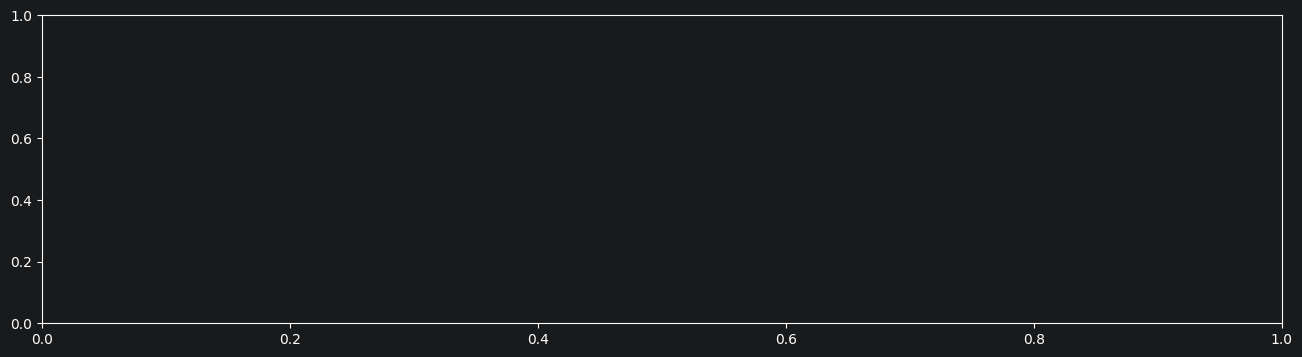

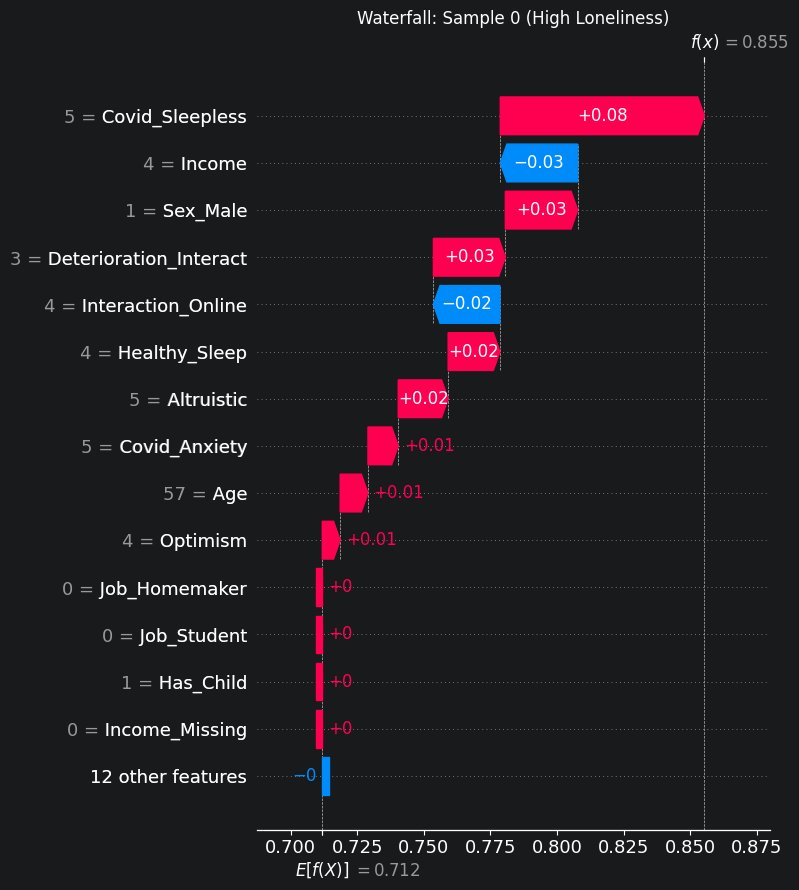

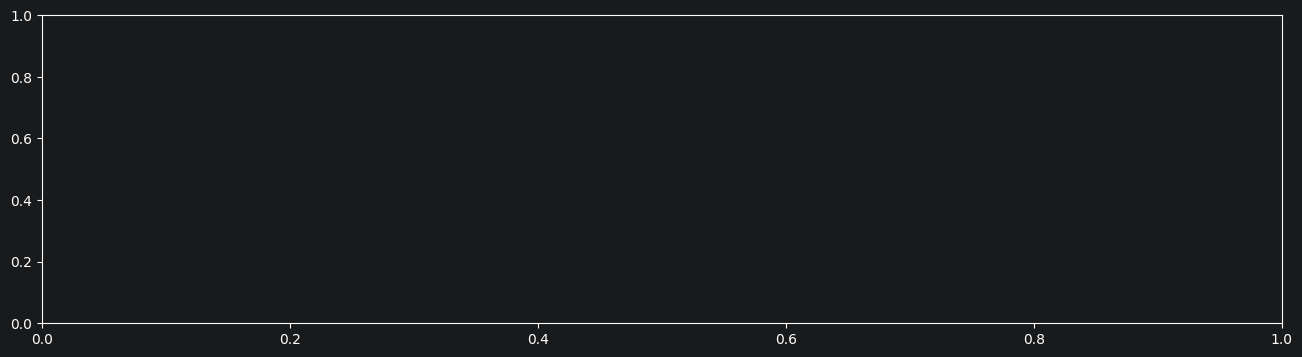

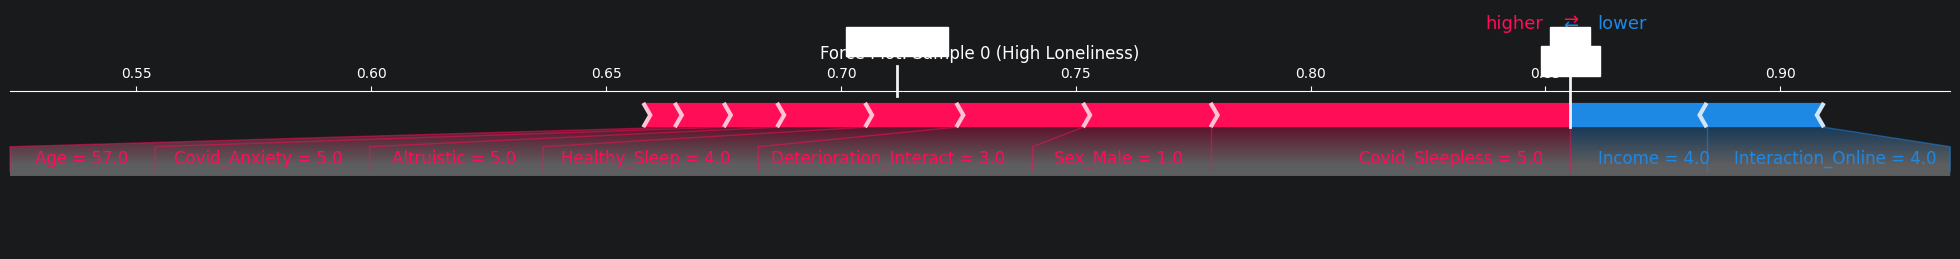

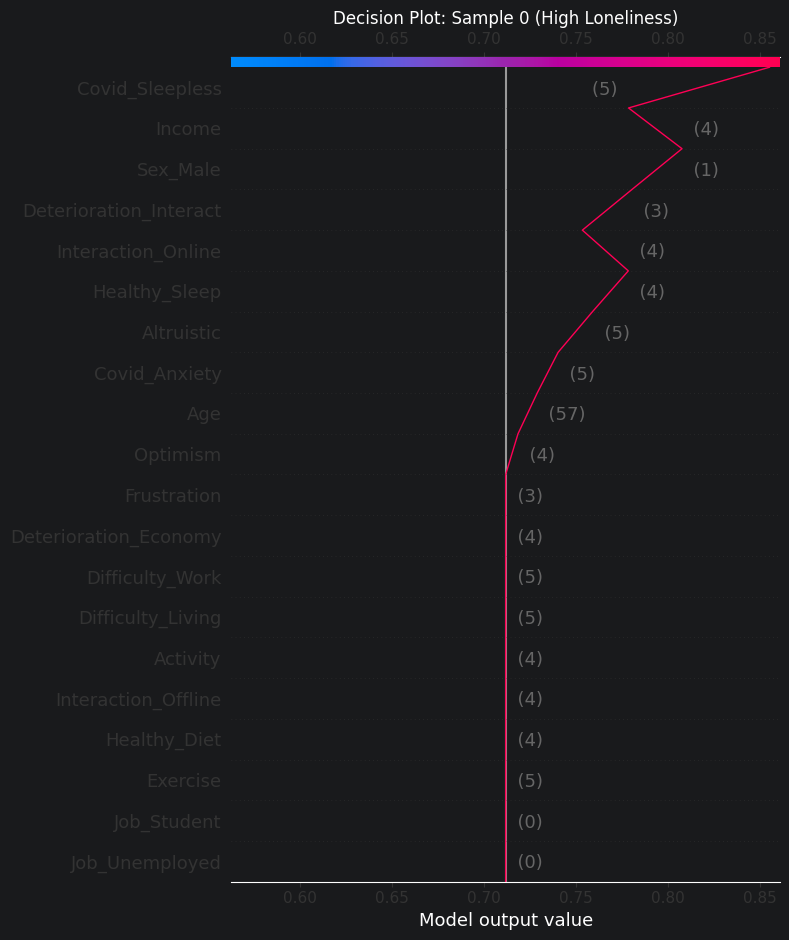

In [54]:
# --- Individual sample explanations ---
# Waterfall, force, and decision plots for a single sample.

sample_idx = 0 # <-- change to inspect a different sample
class_idx = 1 # 0 = Low Loneliness, 1 = High Loneliness

pred = model.predict(X_explain.iloc[[sample_idx]])[0]
prob = model.predict_proba(X_explain.iloc[[sample_idx]])[0]
print(f"Sample {sample_idx}: Predicted = {class_names[pred]}")
print(f"  P(Low)  = {prob[0]:.3f}")
print(f"  P(High) = {prob[1]:.3f}")

# ---- Waterfall plot ----
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx, :, class_idx],
    base_values=shap_explainer.expected_value[class_idx],
    data=X_explain.iloc[sample_idx].values,
    feature_names=features_list
)
fig, ax = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, show=False, max_display=15)
plt.title(f"Waterfall: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.show()

# ---- Force plot ----
shap.initjs()
fig, ax = plt.subplots(figsize=(16, 4))
shap.force_plot(
    shap_explainer.expected_value[class_idx],
    shap_values[sample_idx, :, class_idx],
    X_explain.iloc[sample_idx, :],
    feature_names=features_list,
    matplotlib=True,
    show=False
)
plt.title(f"Force Plot: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.show()

# ---- Decision plot (shows cumulative SHAP contribution) ----
fig, ax = plt.subplots(figsize=(10, 8))
shap.decision_plot(
    shap_explainer.expected_value[class_idx],
    shap_values[sample_idx, :, class_idx],
    X_explain.iloc[sample_idx, :],
    feature_names=features_list,
    show=False
)
plt.title(f"Decision Plot: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.show()

## 3.4 Multi-Sample Decision Plot

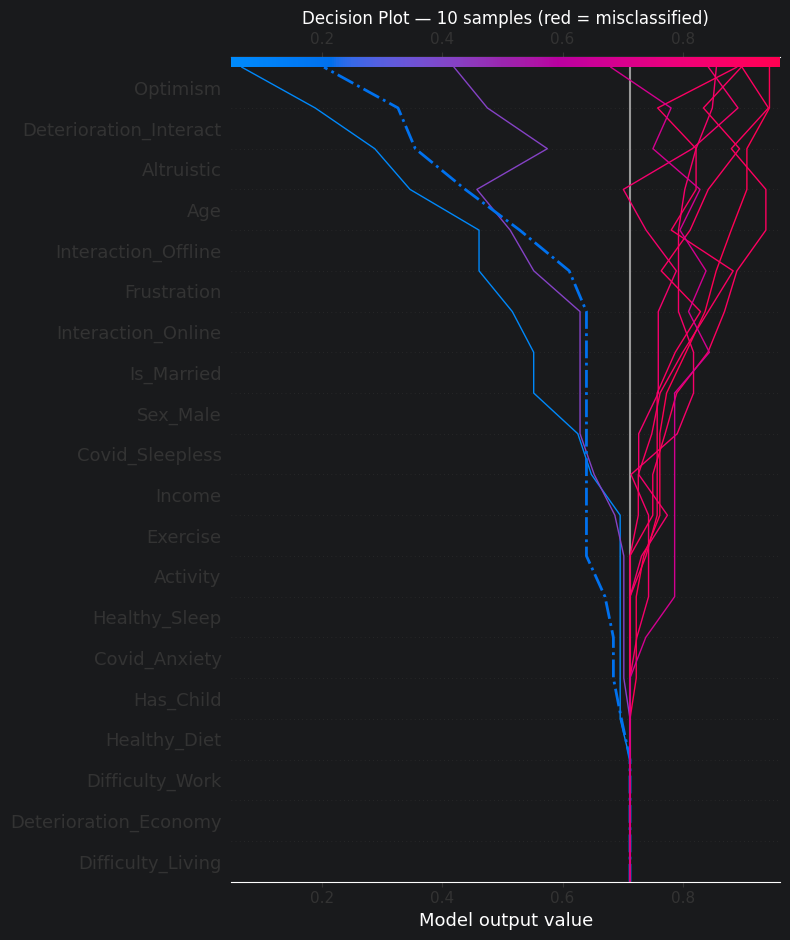

Misclassified: 1/10 (10.0%)


In [55]:
# Decision plot for all explained samples — misclassifications highlighted
y_explain = y_test.iloc[:N_SHAP_EXPLAIN].values
preds_explain = model.predict(X_explain)
misclassified = preds_explain != y_explain

fig, ax = plt.subplots(figsize=(10, 8))
shap.decision_plot(
    shap_explainer.expected_value[1],
    shap_values[:, :, 1],
    X_explain,
    feature_names=features_list,
    highlight=misclassified,
    show=False
)
plt.title(f"Decision Plot — {N_SHAP_EXPLAIN} samples (red = misclassified)")
plt.tight_layout()
plt.show()

n_wrong = misclassified.sum()
print(f"Misclassified: {n_wrong}/{len(preds_explain)} ({100*n_wrong/len(preds_explain):.1f}%)")

# 4. Counterfactual Explanations

In [56]:
# Prepare DiceML data object
df_dice_train = X_train.copy()
df_dice_train[target_UCLA] = y_train.values

continuous_features = features_UCLA.copy()

permitted_range = {} # Binary features clamped to [0, 1]
binary_features = ["Sex_Male", "Is_Married", "Has_Child", "Income_Missing",
                   "Job_Employed", "Job_Homemaker", "Job_Student",
                   "Job_Unemployed", "Job_Other"]
for feat in features_UCLA:
    if feat in binary_features:
        permitted_range[feat] = [0, 1]
    else:
        permitted_range[feat] = [float(X_train[feat].min()),
                                 float(X_train[feat].max())]

dice_data = dice_ml.Data(
    dataframe=df_dice_train,
    continuous_features=continuous_features,
    outcome_name=target_UCLA
)

dice_model = dice_ml.Model(model=model, backend="sklearn")

# method="random" or "genetic" -> slower
dice_exp = dice_ml.Dice(dice_data, dice_model, method="random")

print("DiceML explainer initialized for baseline TabPFN.")
print(f"Continuous features: {len(continuous_features)}")
print(f"Permitted ranges defined for {len(permitted_range)} features.")

DiceML explainer initialized for baseline TabPFN.
Continuous features: 26
Permitted ranges defined for 26 features.


In [57]:
# Single-sample counterfactual
sample_idx = 0 # <-- change to inspect a different sample
test_instance = X_test.iloc[[sample_idx]]

pred = model.predict(test_instance)[0]
prob = model.predict_proba(test_instance)[0]

print(f"Original prediction: {class_names[pred]}")
print(f"Probabilities: Low={prob[0]:.3f}, High={prob[1]:.3f}")
print(f"\nFeature values:")
display(test_instance.T.rename(columns={test_instance.index[0]: "Value"}))

Original prediction: High Loneliness
Probabilities: Low=0.145, High=0.855

Feature values:


,Value
Sex_Male,1
Age,57
Is_Married,1
Has_Child,1
Income,4
Income_Missing,0
Job_Employed,1
Job_Homemaker,0
Job_Student,0
Job_Unemployed,0


In [58]:
# Generate counterfactuals for this sample.
print(f"Generating {N_CF_PER_SAMPLE} counterfactuals...")
start_time = time.time()

dice_result = dice_exp.generate_counterfactuals(
    test_instance,
    total_CFs=N_CF_PER_SAMPLE,
    desired_class="opposite",
    permitted_range=permitted_range,
    random_seed=random_state
)

print(f"Generated in {format_time(time.time() - start_time)}")
print("\n=== Changes Only ===")
dice_result.visualize_as_dataframe(show_only_changes=True)

Generating 3 counterfactuals...


100%|██████████| 1/1 [01:13<00:00, 73.34s/it]

Generated in 1m 13.35s

=== Changes Only ===
Query instance (original outcome : 1)


,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,Job_Student,Job_Unemployed,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
0,1,57,1,1,4,0,1,0,0,0,...,5,3,4,5,5,4,3,5,5,1



Diverse Counterfactual set (new outcome: 0)


,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,Job_Student,Job_Unemployed,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
0,-,83,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0
1,-,88,-,-,-,-,-,1,-,-,...,-,-,-,-,-,-,2,-,-,0
2,0,-,-,-,-,-,-,-,-,-,...,-,-,-,-,2,-,2,-,-,0


In [59]:
print("\n=== Full Counterfactual Details ===")
dice_result.visualize_as_dataframe(show_only_changes=False)


=== Full Counterfactual Details ===
Query instance (original outcome : 1)


,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,Job_Student,Job_Unemployed,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
0,1,57,1,1,4,0,1,0,0,0,...,5,3,4,5,5,4,3,5,5,1



Diverse Counterfactual set (new outcome: 0)


,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,Job_Student,Job_Unemployed,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
0,1,83,1,1,4,0,1,0,0,0,...,5,3,4,5,5,4,3,5,5,0
1,1,88,1,1,4,0,1,1,0,0,...,5,3,4,5,5,4,2,5,5,0
2,0,57,1,1,4,0,1,0,0,0,...,5,3,4,5,2,4,2,5,5,0


## 4.1 Batch Counterfactuals


In [60]:
# Batch counterfactual generation.
cf_results = []

print(f"Generating counterfactuals for {N_CF_SAMPLES} samples "
      f"({N_CF_PER_SAMPLE} CFs each)...")
start_time = time.time()

for idx in range(min(N_CF_SAMPLES, len(X_test))):
    instance = X_test.iloc[[idx]]
    original_pred = model.predict(instance)[0]

    try:
        cf = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=N_CF_PER_SAMPLE,
            desired_class="opposite",
            permitted_range=permitted_range,
            random_seed=random_state
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        if cf_df is not None and len(cf_df) > 0:
            cf_results.append({
                "sample_idx": idx,
                "original_pred": original_pred,
                "original_values": instance.iloc[0].to_dict(),
                "counterfactuals": cf_df.to_dict("records"),
                "n_counterfactuals": len(cf_df)
            })
            print(f"  Sample {idx}: {len(cf_df)} CFs "
                  f"(original: {class_names[original_pred]})")
        else:
            print(f"  Sample {idx}: No valid CFs found")
    except Exception as e:
        print(f"  Sample {idx}: Error — {e}")

elapsed = time.time() - start_time
print(f"\nDone in {format_time(elapsed)}. "
      f"{len(cf_results)}/{N_CF_SAMPLES} successful.")

Generating counterfactuals for 5 samples (3 CFs each)...


100%|██████████| 1/1 [01:15<00:00, 75.56s/it]


  Sample 0: 3 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:18<00:00, 78.72s/it]


  Sample 1: 3 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:19<00:00, 79.05s/it]


  Sample 2: 3 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:05<00:00, 65.58s/it]


  Sample 3: 3 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:05<00:00, 65.50s/it]

  Sample 4: 3 CFs (original: High Loneliness)

Done in 6m 36.34s. 5/5 successful.


## 4.2 Counterfactual Feature Analysis



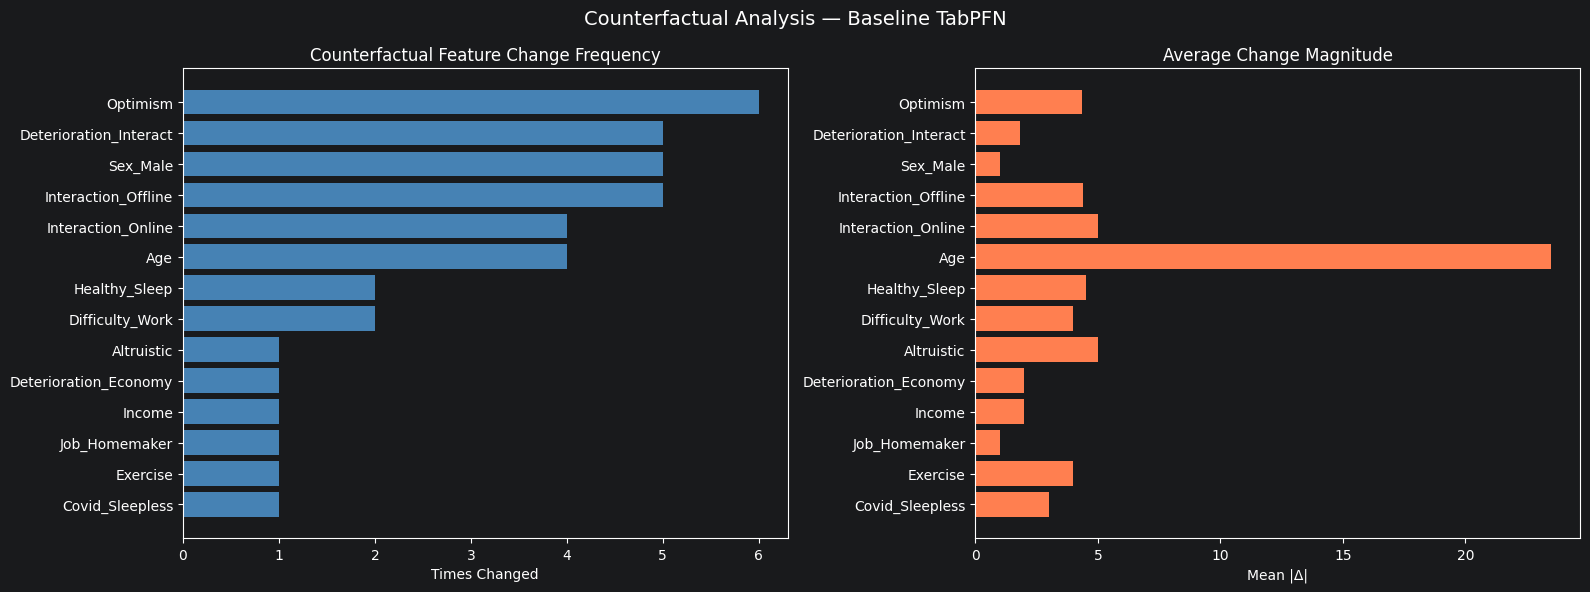

,Feature,Change Count,Avg Magnitude,Dominant Direction
19,Optimism,6,4.333333,decrease
23,Deterioration_Interact,5,1.800000,decrease
0,Sex_Male,5,1.000000,decrease
15,Interaction_Offline,5,4.400000,increase
16,Interaction_Online,4,5.000000,increase
1,Age,4,23.500000,decrease
25,Difficulty_Work,2,4.000000,decrease
14,Healthy_Sleep,2,4.500000,decrease
17,Altruistic,1,5.000000,increase
22,Deterioration_Economy,1,2.000000,increase


In [61]:
feature_change_counts = {feat: 0 for feat in features_UCLA}
feature_change_magnitudes = {feat: [] for feat in features_UCLA}
feature_change_directions = {feat: [] for feat in features_UCLA}

for result in cf_results:
    original = result["original_values"]
    for cf in result["counterfactuals"]:
        for feat in features_UCLA:
            if feat in cf and feat in original:
                diff = cf[feat] - original[feat]
                if abs(diff) > 0.01:
                    feature_change_counts[feat] += 1
                    feature_change_magnitudes[feat].append(abs(diff))
                    feature_change_directions[feat].append(
                        "increase" if diff > 0 else "decrease")

change_df = pd.DataFrame({
    "Feature": list(feature_change_counts.keys()),
    "Change Count": list(feature_change_counts.values()),
    "Avg Magnitude": [np.mean(v) if v else 0
                      for v in feature_change_magnitudes.values()],
    "Dominant Direction": [
        max(set(v), key=v.count) if v else "n/a"
        for v in feature_change_directions.values()
    ]
}).sort_values("Change Count", ascending=True)

# Only show features that actually changed
change_df_nonzero = change_df[change_df["Change Count"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(change_df_nonzero) * 0.4)))

axes[0].barh(change_df_nonzero["Feature"],
             change_df_nonzero["Change Count"], color="steelblue")
axes[0].set_title("Counterfactual Feature Change Frequency")
axes[0].set_xlabel("Times Changed")

axes[1].barh(change_df_nonzero["Feature"],
             change_df_nonzero["Avg Magnitude"], color="coral")
axes[1].set_title("Average Change Magnitude")
axes[1].set_xlabel("Mean |Δ|")

plt.suptitle("Counterfactual Analysis — Baseline TabPFN", fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
display(change_df_nonzero.sort_values("Change Count", ascending=False))

# 5. SHAP vs Counterfactual Comparison


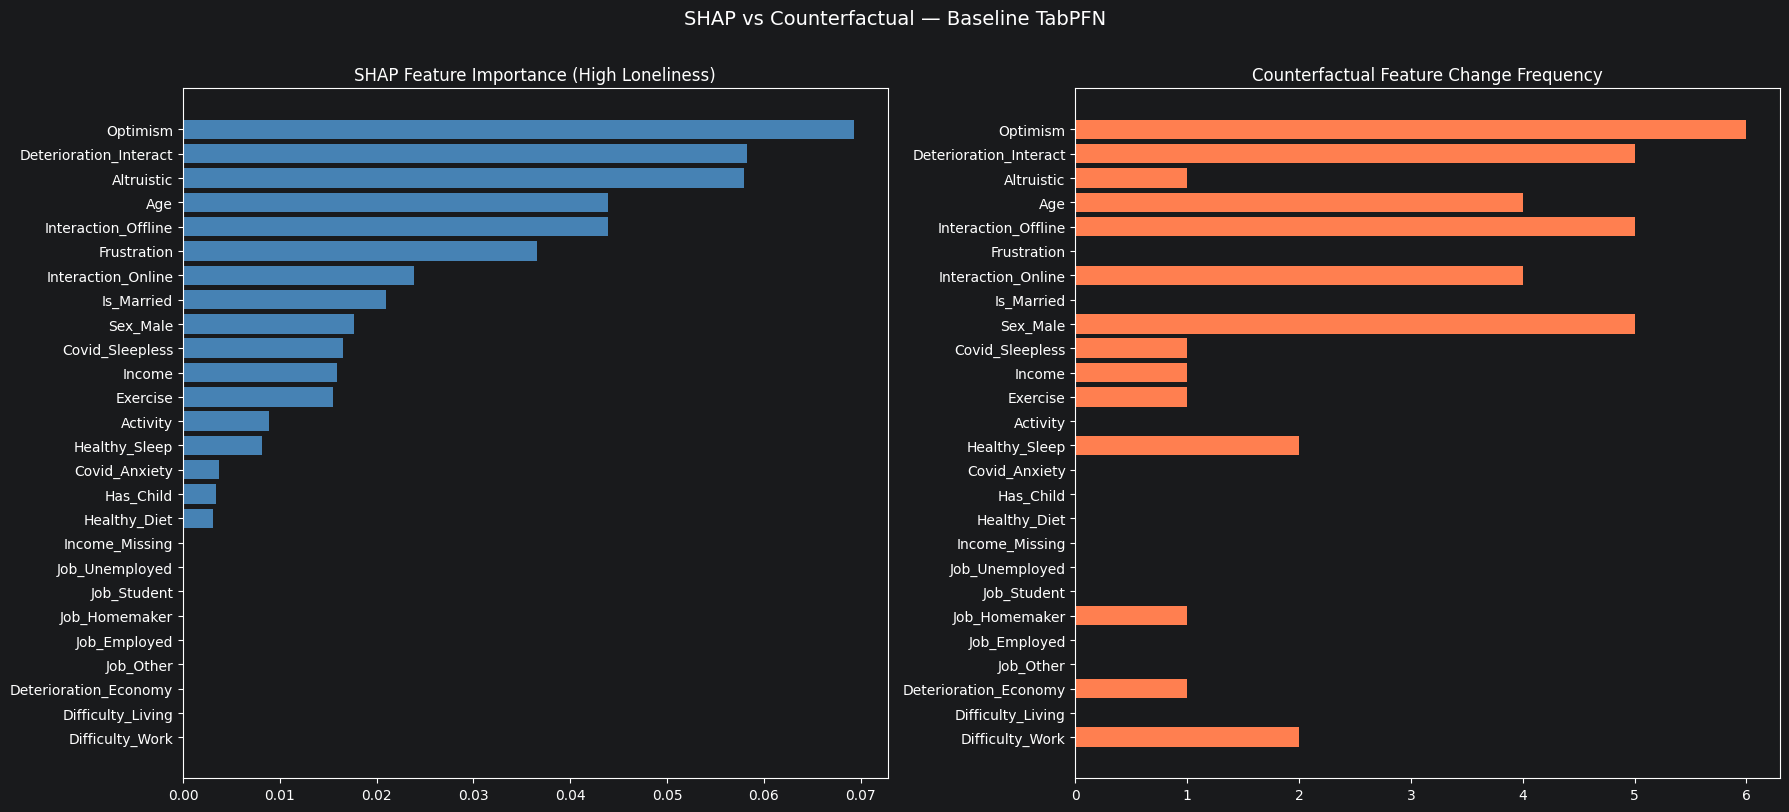

Spearman rank correlation: ρ = 0.596, p = 0.0013
(High ρ means SHAP and counterfactuals agree on feature importance.)



,Feature,SHAP Importance,Change Count
19,Optimism,0.069297,6
23,Deterioration_Interact,0.058282,5
17,Altruistic,0.057903,1
1,Age,0.043920,4
15,Interaction_Offline,0.043871,5
18,Frustration,0.036551,0
16,Interaction_Online,0.023825,4
2,Is_Married,0.020936,0
0,Sex_Male,0.017710,5
21,Covid_Sleepless,0.016536,1


In [63]:
# SHAP importance (High Loneliness class)
class_idx = 1
shap_importance = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": features_list,
    "SHAP Importance": shap_importance
})

combined = shap_df.merge(
    change_df[["Feature", "Change Count"]], on="Feature", how="left"
).fillna(0)
combined = combined.sort_values("SHAP Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(combined["Feature"], combined["SHAP Importance"],
             color="steelblue")
axes[0].set_title("SHAP Feature Importance (High Loneliness)")
axes[0].invert_yaxis()

axes[1].barh(combined["Feature"], combined["Change Count"],
             color="coral")
axes[1].set_title("Counterfactual Feature Change Frequency")
axes[1].invert_yaxis()

plt.suptitle("SHAP vs Counterfactual — Baseline TabPFN",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Rank correlation between the two
from scipy.stats import spearmanr
rho, pval = spearmanr(combined["SHAP Importance"], combined["Change Count"])
print(f"Spearman rank correlation: ρ = {rho:.3f}, p = {pval:.4f}")
print("(High ρ means SHAP and counterfactuals agree on feature importance.)\n")

display(combined)

# 6. Save

In [64]:
# Save counterfactual results
with open("explainers/dice_results.pkl", "wb") as f:
    pickle.dump(cf_results, f)

# Save feature metadata (used by the webapp)
feature_info = {
    "features": features_UCLA,
    "target": target_UCLA,
    "cutoff": UCLA_cutoff,
    "class_names": class_names,
}
with open("explainers/feature_info.pkl", "wb") as f:
    pickle.dump(feature_info, f)

print("All artifacts saved.")

All artifacts saved.
